# Configuración básica y carga de datos

In [1]:
import sys
from pathlib import Path
from IPython.display import display, Image
import ipywidgets as widgets
import seaborn as sns
import pandas as pd

# Rutas
PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "data" / "Results"
SELECTED_DIR = DATA_PROCESSED / "selected"
EDGE_FILES = [
    DATA_PROCESSED / "edgeData_scen1.csv",
    DATA_PROCESSED / "edgeData_scen2.csv",
]

NET_FILE = DATA_RAW / "simulation" / "algeciras.net.xml"
NET_XML = DATA_RAW / "simulation" / "algeciras.net.xml"


sys.path.append(str(PROJECT_ROOT))

from src.milp_solve import load_milp_inputs, solve_sensor_placement
from src.evaluation import compute_flow_coverage
from scripts import make_sensor_pois
from src.evaluation import compare_milp_vs_ga

# Cargar milp_inputs (si no lo tienes ya cargado)
milp_inputs = load_milp_inputs()



# Cargamos milp_inputs ya preprocesado
milp_inputs = load_milp_inputs()

print("Claves disponibles en milp_inputs:", milp_inputs.keys())
print("Ejemplo flows:")
display(milp_inputs["flows"].head())
print("Ejemplo edges:")
display(milp_inputs["edges"].head())

Claves disponibles en milp_inputs: dict_keys(['flows', 'edges', 'nodes', 'entry_nodes', 'exit_nodes', 'O', 'D', 'M'])
Ejemplo flows:


,scenario,edge_id,tau,begin,end,flow_veh_s,flow_veh_h
0,scen1,-1097680628#0,0,0.0,60.0,0.000000,0.0
1,scen1,-1108932288#2,0,0.0,60.0,0.016667,60.0
2,scen1,-1108932289#0,0,0.0,60.0,0.033333,120.0
3,scen1,-1108932289#1,0,0.0,60.0,0.016667,60.0
4,scen1,-1312203992,0,0.0,60.0,0.000000,0.0


Ejemplo edges:


,edge_id,from_node,to_node
0,-1097680628#0,6380710388,288435676
1,-1108932288#0,12145934094,6295741084
2,-1108932288#1,12145934075,12145934094
3,-1108932288#2,10146578305,12145934075
4,-1108932289#0,5244158193,10146578306


# Re-ejecutar preprocesamiento completo

In [ ]:
from src import preprocessing


print("Usando edgeData:")
for p in EDGE_FILES:
    print("  -", p)

print("Usando red:", NET_FILE)

milp_inputs = preprocessing.construir_milp_inputs(
    edgeData_paths=EDGE_FILES,
    net_path=NET_FILE,
    processed_dir=DATA_PROCESSED,
)

print("\nPreprocesamiento completado. milp_inputs.pkl actualizado.")
print("Claves:", milp_inputs.keys())

# Ejecutar el MILP con B sensores

In [ ]:
from scripts.run_milp import run_milp_experiment

# Ejecutar MILP con B sensores y guardar selección en data/processed/selected
milp_run = run_milp_experiment(
    B=100,
    selection_dir=DATA_PROCESSED / "selected",
)


display(milp_run["df_cov"])

milp_run

# Ejecutar Algoritmo Genético (GA)

=== Ejecutando Algoritmo Genético para Sensores ===
CSV de entrada: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen1.csv
Usando net.xml: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\raw\simulation\algeciras.net.xml
Leyendo red desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\raw\simulation\algeciras.net.xml
Sistema inicializado: 699 tramos, 965 ecuaciones de conservación.
Número total de tramos (edges): 699
Iniciando Algoritmo Genético...
gen	nevals	min    	avg    
0  	50    	2.96406	3.37727
1  	47    	2.93436	15403.2
2  	42    	2.88904	4003.16
3  	35    	2.88838	3003.06
4  	42    	2.87011	3603.03
5  	46    	2.87011	1803.01
6  	39    	2.87011	602.927
7  	45    	2.86772	2.89157
8  	32    	2.84933	2.8775 
9  	40    	2.85216	2.8716 
10 	46    	2.83394	2.86746
11 	46    	2.83394	2.86347
12 	41    	2.83007	2.85483
13 	41    	2.80581	2.8464 
14 	45    	2.80221	2.83602
15 	38    	2.80079	2.82263
16 	44    	2.80079	2.8139 
17 	40    	2.7857

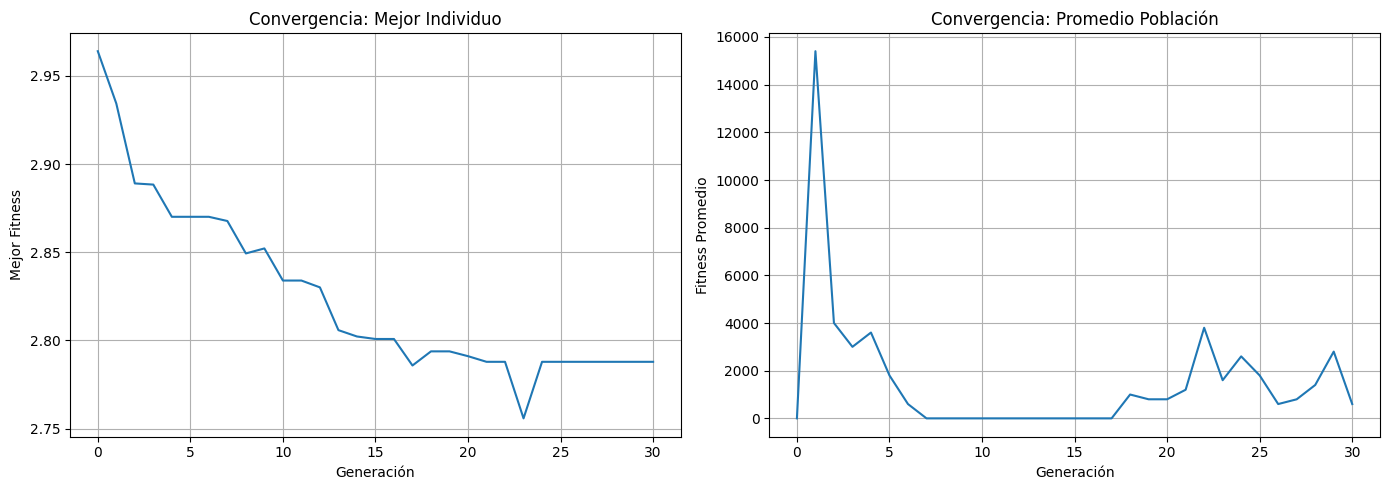

Solución visualizada. Sensores: 20. Fitness (RMSE + penalización): 2.7558


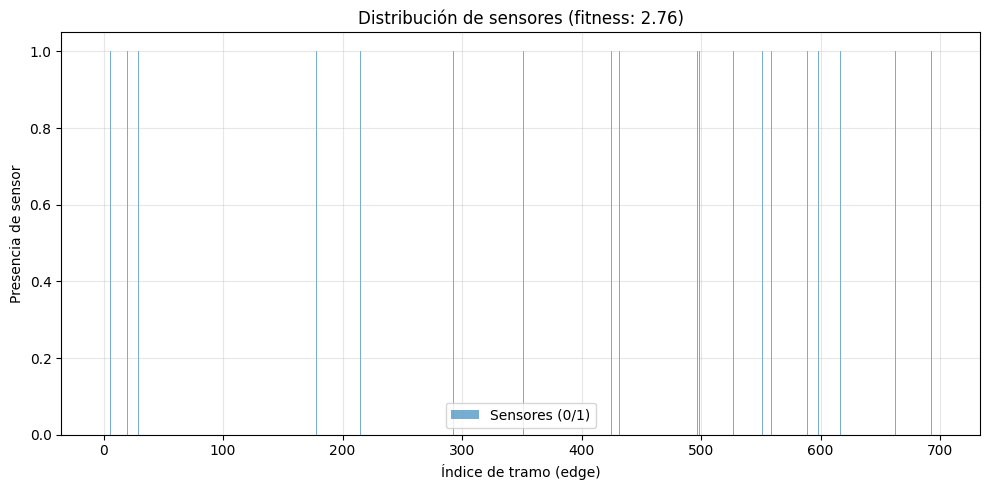

{'best': [0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  

In [2]:
from scripts.run_ga import run_ga_experiment

ga_result = run_ga_experiment(
    csv_path=DATA_PROCESSED / "edgeData_scen1.csv",
    population_size=50,
    max_generations=30,
    sensor_budget=20,
    net_xml_path=PROJECT_ROOT / "data" / "raw" / "simulation" / "algeciras.net.xml",
)
ga_result

# Generación de additionals en SUMO

In [18]:
import re
from scripts import make_sensor_pois as mpois

NET_XML = DATA_RAW / "simulation" / "algeciras.net.xml"

# Calculamos los shapes una sola vez (más eficiente)
edge_shapes = mpois.cargar_shapes_net(NET_XML)
print(f"Shapes disponibles para {len(edge_shapes)} edges en {NET_XML}")

# Recorremos TODOS los selected_edges_B*.txt (MILP y GA)
for txt_path in sorted(SELECTED_DIR.glob("selected_edges_B*.txt")):
    print(f"\nProcesando {txt_path.name} ...")
    edge_ids = mpois.leer_selected_edges(txt_path)

    stem = txt_path.stem  # p.ej. "selected_edges_B25" o "selected_edges_B99_GA"

    # Buscar el patrón "_B<number>" en el nombre
    m = re.search(r"_B(\d+)", stem)
    if not m:
        print("  (no se pudo extraer B del nombre, se omite)")
        continue

    B = int(m.group(1))

    # Sufijo extra después de "_B<number>" (por ejemplo "_GA" o nada)
    suffix = stem[m.end():]  # desde donde acaba el número hasta el final

    # Construimos el nombre del .add.xml manteniendo el sufijo si existe
    #   selected_edges_B25.txt      → sensors_B25.add.xml
    #   selected_edges_B99_GA.txt   → sensors_B99_GA.add.xml
    if suffix:
        output_add = SELECTED_DIR / f"sensors_B{B}{suffix}.add.xml"
    else:
        output_add = SELECTED_DIR / f"sensors_B{B}.add.xml"

    mpois.escribir_pois(output_add, edge_ids, edge_shapes)

Shapes disponibles para 6912 edges en C:\Users\ignag\OneDrive\Documentos\TSLP\algeciras_milp_borrador\data\raw\simulation\algeciras.net.xml

Procesando selected_edges_B10.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP\algeciras_milp_borrador\data\processed\selected\sensors_B10.add.xml

Procesando selected_edges_B13.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP\algeciras_milp_borrador\data\processed\selected\sensors_B13.add.xml

Procesando selected_edges_B15.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP\algeciras_milp_borrador\data\processed\selected\sensors_B15.add.xml

Procesando selected_edges_B20.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP\algeciras_milp_borrador\data\processed\selected\sensors_B20.add.xml

Procesando selected_edges_B20_GA.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP\algeciras_milp_borrador\data\proces

# Dashboard sencillo de imágenes de configuración de sensores

In [ ]:
def show_milp_image(B: int):
    """
    Muestra la imagen de resultados del MILP almacenada en:
        data/Results/{B}_MILP.png
    """
    img_path = RESULTS_DIR / f"{B}_MILP.png"
    if not img_path.exists():
        print(f"No se encontró la imagen {img_path}")
        return
    display(Image(filename=str(img_path)))

# Widget: deslizador para elegir B (ajusta el rango a tus valores disponibles)
B_slider = widgets.IntSlider(
    value=20,
    min=15,
    max=40,
    step=5,
    description="Sensors B:",
    continuous_update=False,
)

ui = widgets.VBox([B_slider])

out = widgets.Output()

def on_B_change(change):
    if change["name"] == "value":
        B = change["new"]
        out.clear_output()
        with out:
            print(f"Configuración de sensores para B = {B}")
            show_milp_image(B)

B_slider.observe(on_B_change, names="value")

display(ui, out)

# Llamada inicial
on_B_change({"name": "value", "new": B_slider.value})

In [10]:
def show_GA_image(B: int):
    """
    Muestra la imagen de resultados del GA almacenada en:
        data/Results/{B}_GA.png
    """
    img_path = RESULTS_DIR / f"{B}_GA.png"
    if not img_path.exists():
        print(f"No se encontró la imagen {img_path}")
        return
    display(Image(filename=str(img_path)))

# Widget: deslizador para elegir B (ajusta el rango a tus valores disponibles)
B_slider = widgets.IntSlider(
    value=20,
    min=20,
    max=98,
    step=10,
    description="Sensors B:",
    continuous_update=False,
)

ui = widgets.VBox([B_slider])

out = widgets.Output()

def on_B_change(change):
    if change["name"] == "value":
        B = change["new"]
        out.clear_output()
        with out:
            print(f"Configuración de sensores para B = {B}")
            show_GA_image(B)

B_slider.observe(on_B_change, names="value")

display(ui, out)

# Llamada inicial
on_B_change({"name": "value", "new": B_slider.value})

Output()

In [6]:
df_comp = compare_milp_vs_ga(
    milp_inputs=milp_inputs,
    selected_dir=SELECTED_DIR,
    results_dir=RESULTS_DIR / "evaluation",
)

display(df_comp)

Budgets B comunes encontrados (MILP & GA): [20]

=== Comparando B = 20 ===
Figura de comparación guardada en: C:\Users\ignag\OneDrive\Documentos\TSLP\algeciras_milp_borrador\data\Results\evaluation\comparison_MILP_vs_GA_B20.png


,B,algo,scenario,total_flow_veh_h,sensed_flow_veh_h,coverage_ratio
0,20,MILP,ALL,8697120.0,39240.0,0.004512
1,20,GA,ALL,8697120.0,714900.0,0.082200


# Simulated Annealing (SA)

In [6]:
from src.sa_algorithm import SimulatedAnnealing, build_domain_from_preprocessing
from src.ga_algorithm import save_ga_solution  # la función ya sabe leer domain.edge_ids

# 1) Construir dominio a partir del preprocessing
#    (usa los edgeData_scen*.csv y genera un flujo medio por edge)
domain = build_domain_from_preprocessing()

budget = 20

print(f"Running SA with B={budget}...")
sa = SimulatedAnnealing(
    domain=domain,
    budget=budget,
    max_iter=250,
    initial_temp=1000.0,
)

sa_result = sa.run(seed=42)

print("Best SA Fitness (uncovered flow):", sa_result["best_fitness"])
print("Active sensors in best solution:", int(sa_result["best_solution"].sum()))

# 2) Guardar solución en formato compatible con SUMO/NETEDIT
output_sa_path = DATA_PROCESSED / "selected" / f"selected_edges_B{budget}_SA.txt"
save_ga_solution(sa_result["best_solution"], domain, output_sa_path)
print(f"SA Solution saved to {output_sa_path}")


Cargando edgeData desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen1.csv
Cargando edgeData desde: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\edgeData_scen2.csv
No se encontró 'nVehContrib'. Usando 'entered' para el flujo.
[build_domain_from_preprocessing] Dominio construido con 699 edges.
Running SA with B=20...
Best SA Fitness (uncovered flow): 137959.0986143782
Active sensors in best solution: 20
[GA] Solución guardada en: C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\selected_edges_B20_SA.txt
SA Solution saved to C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\processed\selected\selected_edges_B20_SA.txt


# Multi-Seed Experiments & Variance Analysis

Sistema inicializado: 699 tramos, 389 ecuaciones de conservación.
Running Multi-seed GA...


Running GA B=20: 100%|██████████| 5/5 [04:37<00:00, 55.41s/it]


Running Multi-seed SA...


Running SA B=20: 100%|██████████| 5/5 [01:45<00:00, 21.15s/it]


,count,mean,std,min,25%,50%,75%,max
algorithm,,,,,,,,
GA,5.0,3.754392,0.127490,3.632969,3.647990,3.729031,3.825058,3.936911
SA,5.0,3.771109,0.144439,3.553103,3.707729,3.805119,3.886071,3.903523


Plot saved to C:\Users\ignag\OneDrive\Documentos\TSLP_algeciras\data\Results\variance_analysis.png


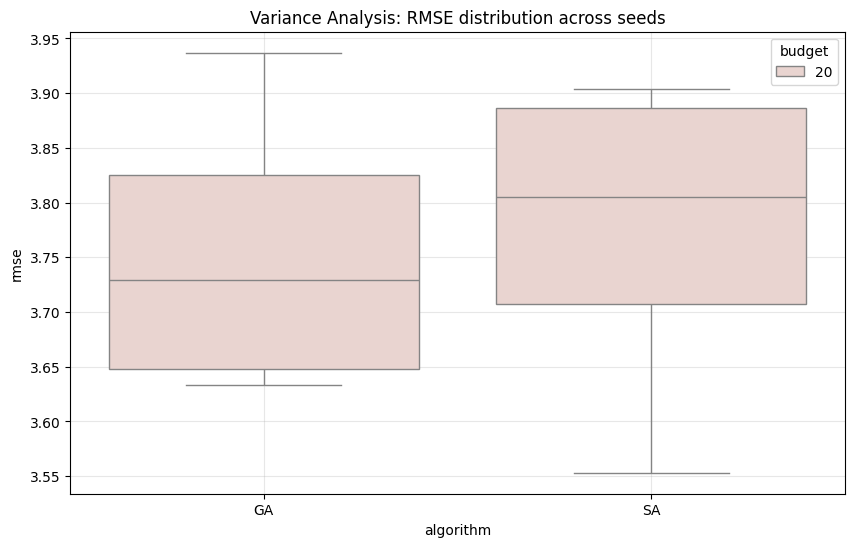

In [5]:
from src.experiments import run_multi_seed_experiment, plot_variance_analysis
import pandas as pd

from src.ga_algorithm import TrafficNetwork
from src.sa_algorithm import SimulatedAnnealing

network = TrafficNetwork(DATA_PROCESSED / "edgeData_scen1.csv")

# Define seeds
seeds = [42, 10, 2023, 777, 99]
budget = 20

# Run GA
print("Running Multi-seed GA...")
df_ga = run_multi_seed_experiment(
    network,
    "GA",
    budget,
    seeds,
    population_size=50,
    max_generations=10,
)

# Run SA (mismos seeds, misma B, pero con hiperparámetros de SA)
print("Running Multi-seed SA...")
df_sa = run_multi_seed_experiment(
    network,
    "SA",
    budget,
    seeds,
    max_iter= 500,
    initial_temp=5000.0,   
    cooling_rate=0.95,     
    min_temp=1.0,          
)
# Combine results
df_all = pd.concat([df_ga, df_sa], ignore_index=True)

# Display results (misma métrica RMSE para GA y SA)
display(df_all.groupby("algorithm")["rmse"].describe())

# Plot Variance
output_plot = RESULTS_DIR / "variance_analysis.png"
plot_variance_analysis(df_all, output_path=output_plot)